# ADE Surfaces: Del Pezzo and Anticanonical Log Pairs

## 1. Mathematical Framework
Following **Alexeev-Thompson** (*"ADE surfaces and their moduli"*, 2021, [arXiv:1712.07932](https://arxiv.org/abs/1712.07932)), ADE surfaces are classified via dual log pairs:

1. **Covering Anticanonical Log Pair** $(X, D + \varepsilon R)$:
   - $X = \mathrm{V}(w^2 + f(x, y)) \subset V_P$ is a codimension $1$ hypersurface in a polarized toric threefold $V_P$.
   - $P = \operatorname{conv}(Q \times \{0\} \cup \{(p^*, 2)\}) \subset \mathbb{Z}^3$ is the $3$D pyramidal lattice polytope.
   - $D = \pi^*(C)$ is the preimage boundary divisor, and $R$ is the ramification divisor.

2. **Base Del Pezzo Log Pair** $(Y, C + \frac{1+\varepsilon}{2} B)$:
   - $Y = V_Q \subset V_Q$ is a $2$D toric del Pezzo surface defined by the normal fan of the lattice polygon $Q \subset \mathbb{Z}^2$.
   - $C = \sum_{p^* \in F_i} D_{F_i}$ is the distinguished boundary divisor ("blue line").
   - $B = \mathrm{V}(f(x, y))$ is the branch divisor cut out by the section $f \in H^0(Y, -2K_Y)$.

Both $(X, D)$ and $(Y, C)$ land in a unified subcategory of **subobjects of toric varieties** (`ToricSubscheme` $\in$ `ADELogPairs`). Passing between $X$ and $Y$ via `.base()` and `.cover()` preserves all algebraic, geometric, and Dynkin data bidirectionally.


## 2. Category Integration & Toric Subcategory Tree

The preamble defines the category hierarchy for schemes, toric varieties, and log pairs:
```
Schemes(S)
  └── Varieties(S)
        ├── ToricSchemes(S) ─────────────> ToricScheme (V_P, V_Q)
        │     └── .Subobject ────────────> ToricSubscheme (X ⊂ V_P, Y = V_Q)
        │
        └── LogPairs(S)
              └── ADELogPairs(S) ────────> ADELogPair (Cover & Base)
                                            ├── ADESurface (X ⊂ V_P, D)
                                            └── ADEBaseSurface (Y ⊂ V_Q, C)
```

In [1]:
from sage.all import *
from dzack_research.preamble.categories.schemes.ade_surfaces import (
    LogPairs,
    ADELogPairs,
    ADELogPair,
    ADESurface,
    ADEBaseSurface,
    SideDecoration,
)
from dzack_research.preamble.categories.schemes.toric import (
    ToricSchemes,
    ToricScheme,
    ToricSubscheme,
)

show(ToricSchemes(QQ))
show(LogPairs())
show(ADELogPairs())

Category of toric schemes over Rational Field

Category of log pairs

Category of a d e surfaces (Y, C)

## 3. Constructing Pure & Primed ADE Surfaces

`ADESurface` is instantiated using Dynkin letter, rank, and a **tuple of side decorations** for sides adjacent to $p_*$.

In [2]:
# Construct sample surfaces
A3 = ADESurface("A", 3, variant=("long", "long"))
A3_prime = ADESurface("A", 3, variant=("primed",))
D4 = ADESurface("D", 4)
D4_prime = ADESurface("D", 4, variant=("primed",))
E6 = ADESurface("E", 6)
E8 = ADESurface("E", 8)
tilde_E8 = ADESurface("E", 8, affine=True)

# Evaluating the 3D ADE covering surface hypersurface X renders its 3D LaTeX description and interactive 3D Three.js cover polytope P
A3

Log Pair (X, D + eps*R) where X = V(w^2 + (-1/4*x^2*y^2 + x^2 + y)) ⊂ PP(1,1,2,2) of type A_3 (D + eps*R = V(z0, -1/4*x^2*y^2 + w^2 + x^2 + y) + V(z2, -1/4*x^2*y^2 + w^2 + x^2 + y) + eps*V(w, -1/4*x^2*y^2 + x^2 + y))

In [3]:
# Evaluating the 2D base del Pezzo log pair renders its 2D LaTeX description and 2D polygon plot of Q
A3.base()

Log Pair (Y, C + 1/2(1+eps)B) where Y = PP(1,1,2) of type A_3 (C + 1/2(1+eps)B = V(z0) + V(z2) + 1/2(1+eps)*V(-1/4*x^2*y^2 + x^2 + y), p* = (0, 2))

## 4. Uniform Invariants & Bidirectional Pairing ($X \longleftrightarrow Y$)

$X$ and $Y$ are dual log pairs and categorical subobjects of ambient toric varieties:
- **Geometric Data**: Defining equations cutting out $X \subset V_P$ or $Y = V_Q \subset V_Q$, along with ambient variety identification (e.g. $V_P$, $V_Q$, $\mathbb{P}^2$, $\mathbb{P}^3$).
- **Ambient Polytope Matrix**: Integer coordinate matrix $M$ whose convex hull is the polarizing polytope $P = \operatorname{conv}(\operatorname{rows}(M))$.
- **Integral Invariants**: Normalized volume $\operatorname{Vol}_\mathbb{Z}$, lattice point count $|P \cap \mathbb{Z}^n|$, interior point count $|\operatorname{Int}(P) \cap \mathbb{Z}^n|$, and boundary point count.
- **Bidirectional Data Preservation**: $X.\operatorname{base}().\operatorname{cover}() \equiv X$ and $Y.\operatorname{cover}().\operatorname{base}() \equiv Y$.


In [4]:
# Bidirectional pairing: passing between X and Y preserves all data without loss
assert A3.base().cover() is A3
assert A3.cover() is A3
assert A3.base().base() is A3.base()

print("=== Uniform Log Pair Invariants & Computed Divisors ===")
for label, pair in [("Covering Anticanonical Pair (X, D + eps*R)", A3), ("Base Del Pezzo Pair (Y, C + 1/2(1+eps)B)", A3.base())]:
    print(f"\n--- {label} ---")
    print(f"  Log Pair:               {repr(pair)}")
    print(f"  ADE Singularity Type:   {pair.ade_type()} (Cartan: {pair.cartan_type()})")
    print(f"  Ambient Toric Variety:  {pair.ambient_identification()} (dim={pair.ambient_dimension()})")
    print(f"  Scheme Equations:       {pair.equations()} (dim={pair.dimension()}, codim={pair.codimension()})")
    print(f"  Boundary Divisor:       {repr(pair.boundary_divisor())}")
    if pair.is_cover():
        print(f"  Ramification Divisor R: {repr(pair.ramification_divisor())}")
    else:
        print(f"  Branch Divisor B:       {repr(pair.branch_divisor())}")
    print(f"  Full Log Divisor:       {repr(pair.log_divisor())}")
    print(f"  Integral Invariants:    {pair.integral_invariants()}")
    print(f"  Ambient Polytope Matrix (conv(rows) = P):\n{pair.polytope_matrix()}")


=== Uniform Log Pair Invariants & Computed Divisors ===

--- Covering Anticanonical Pair (X, D + eps*R) ---
  Log Pair:               Log Pair (X, D + eps*R) where X = V(w^2 + (-1/4*x^2*y^2 + x^2 + y)) ⊂ PP(1,1,2,2) of type A_3 (D + eps*R = V(z0, -1/4*x^2*y^2 + w^2 + x^2 + y) + V(z2, -1/4*x^2*y^2 + w^2 + x^2 + y) + eps*V(w, -1/4*x^2*y^2 + x^2 + y))
  ADE Singularity Type:   A_3 (Cartan: ['A', 3])
  Ambient Toric Variety:  PP(1,1,2,2) (dim=3)
  Scheme Equations:       (-1/4*x^2*y^2 + x^2 + w^2 + y,) (dim=2, codim=1)
  Boundary Divisor:       V(z0, -1/4*x^2*y^2 + w^2 + x^2 + y) + V(z2, -1/4*x^2*y^2 + w^2 + x^2 + y)
  Ramification Divisor R: V(w, -1/4*x^2*y^2 + x^2 + y) ⊂ PP(1,1,2,2)
  Full Log Divisor:       V(z0, -1/4*x^2*y^2 + w^2 + x^2 + y) + V(z2, -1/4*x^2*y^2 + w^2 + x^2 + y) + eps*V(w, -1/4*x^2*y^2 + x^2 + y)
  Integral Invariants:    {'dimension': 3, 'volume': 8/3, 'normalized_volume': 16, 'n_integral_points': 14, 'n_interior_points': 0, 'n_boundary_points': 14}
  Ambient Polytope

## 5. Universal Parametric Branch Polynomials $f(x, y; c_i)$

Following Section 3.1, Equations (3.4)--(3.6) of Alexeev-Thompson [AT21], the universal branch curve equations $B = \text{div}(f)$ are parameterized by fundamental characters $c = \chi(\varpi_i)$ on the root lattice:
- $\mathbf{A_n'}: f(x, y) = -\left(\frac{xy - c''}{2}\right)^2 + y + c_0 + c_1 x + \dots + x^{n-1}$
- $\mathbf{D_n}: f(x, y) = -\left(\frac{xy - c''}{2}\right)^2 + y^2 + c_1' y + c_0 + c_1 x + \dots + x^{n-2}$
- $\mathbf{E_n}: f(x, y) = -\left(\frac{xy - c''}{2}\right)^2 + y^3 + c_2' y^2 + c_1' y + c_0 + \dots + x^{n-3}$

In [5]:
show(A3.parametric_branch_polynomial())
show(D4.parametric_branch_polynomial())
show(E6.parametric_branch_polynomial())
show(E8.parametric_branch_polynomial())


-1/4*x^2*y^2 + x^2*c2 + 1/2*x*y*c_pp + x^2 + x*c1 - 1/4*c_pp^2 + y + c2

-1/4*x^2*y^2 + 1/2*x*y*c_pp + x^2 + y^2 + x*c1 + y*cp1 - 1/4*c_pp^2 + c2

-1/4*x^2*y^2 + x^3 + y^3 + x^2*c1 + y^2*cp1 + 1/2*x*y*c_pp + x*c2 + y*cp2 - 1/4*c_pp^2 + c3

x^5 + x^4*c1 - 1/4*x^2*y^2 + x^3*c2 + y^3 + x^2*c3 + y^2*cp1 + 1/2*x*y*c_pp + x*c4 + y*cp2 - 1/4*c_pp^2 + c5

## 6. Interior Dynkin Diagram Trees in Polytopes

Following Notation 821--838 of [AT21], the Dynkin diagram is embedded directly inside the polytope $Q$:
- Boundary nodes along $\partial Q \setminus C$: colored black (lattice length 2 from $p_*$) or white (lattice length 1 from $p_*$).
- Internal nodes for corners not in $C$: circled white nodes connected diagonally to the corner.

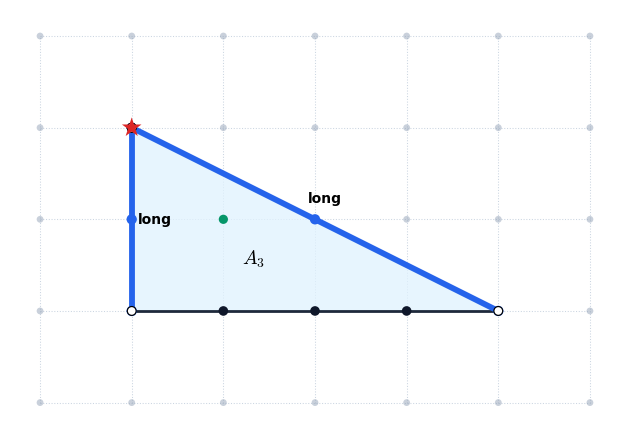

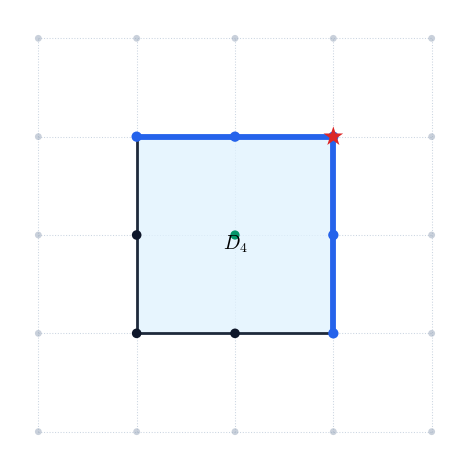

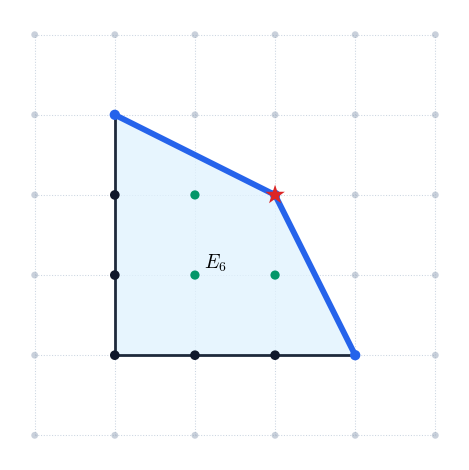

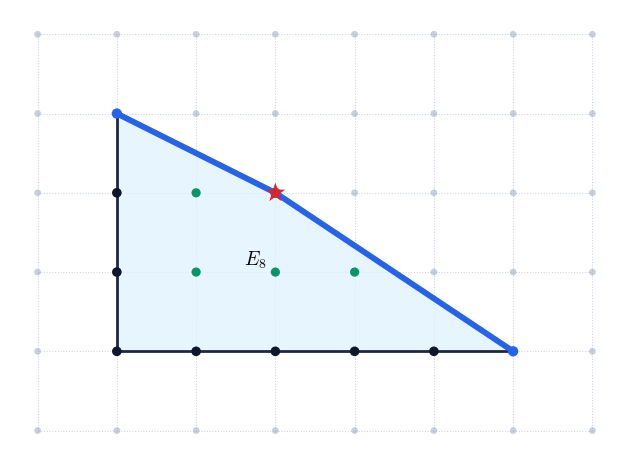

In [6]:
for s in [A3, D4, E6, E8]:
    show(s.base().plot(show_dynkin_diagram=True))

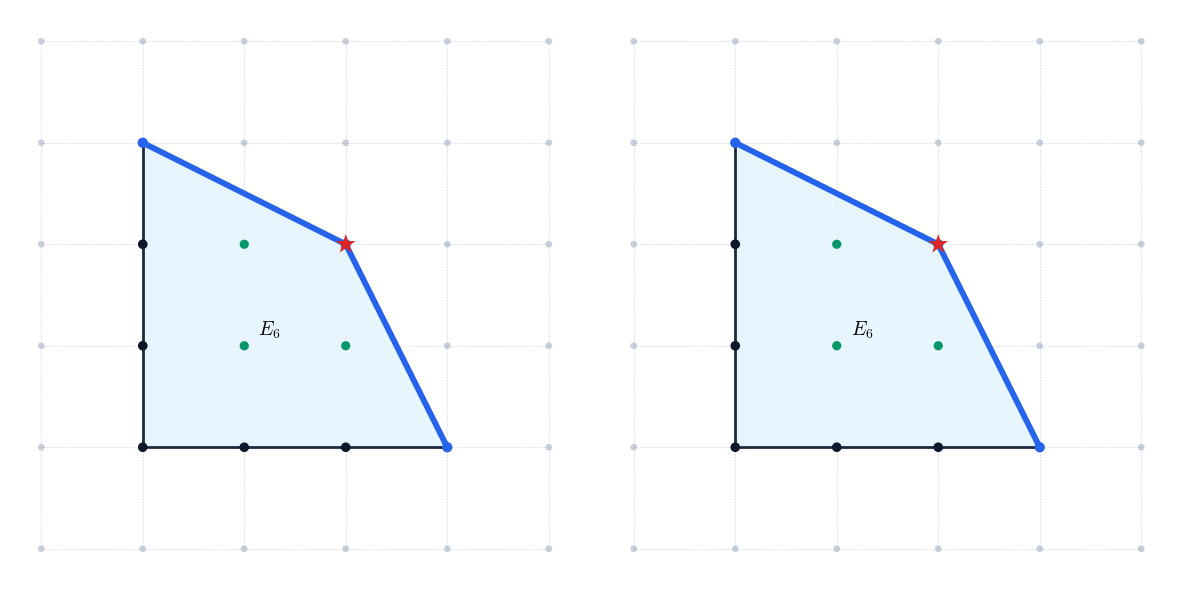

In [7]:
from sage.plot.multigraphics import GraphicsArray

p_e6_plain = E6.base().plot(show_dynkin_diagram=False)
p_e6_dynkin = E6.base().plot(show_dynkin_diagram=True)

GraphicsArray([[p_e6_plain, p_e6_dynkin]]).show(figsize=[12, 6])

## 7. Generating the Complete 12-Polytope Publication Gallery & Assets

Construct all 12 canonical ADE surfaces, render the full $4 \times 3$ publication gallery, and export all standalone vector PDF and raster PNG files to `ade_polytopes_publication/`.

  ✓ Exported A_3
  ✓ Exported A_2_minus


  ✓ Exported minus_A_1
  ✓ Exported D_4
  ✓ Exported E_6


  ✓ Exported minus_E_7
  ✓ Exported E_8
  ✓ Exported tilde_D_6


  ✓ Exported tilde_E_6
  ✓ Exported tilde_E_7
  ✓ Exported tilde_E_8


  ✓ Exported tilde_A_3



  ✓ Exported ade-gallery.pdf and ade_gallery.png


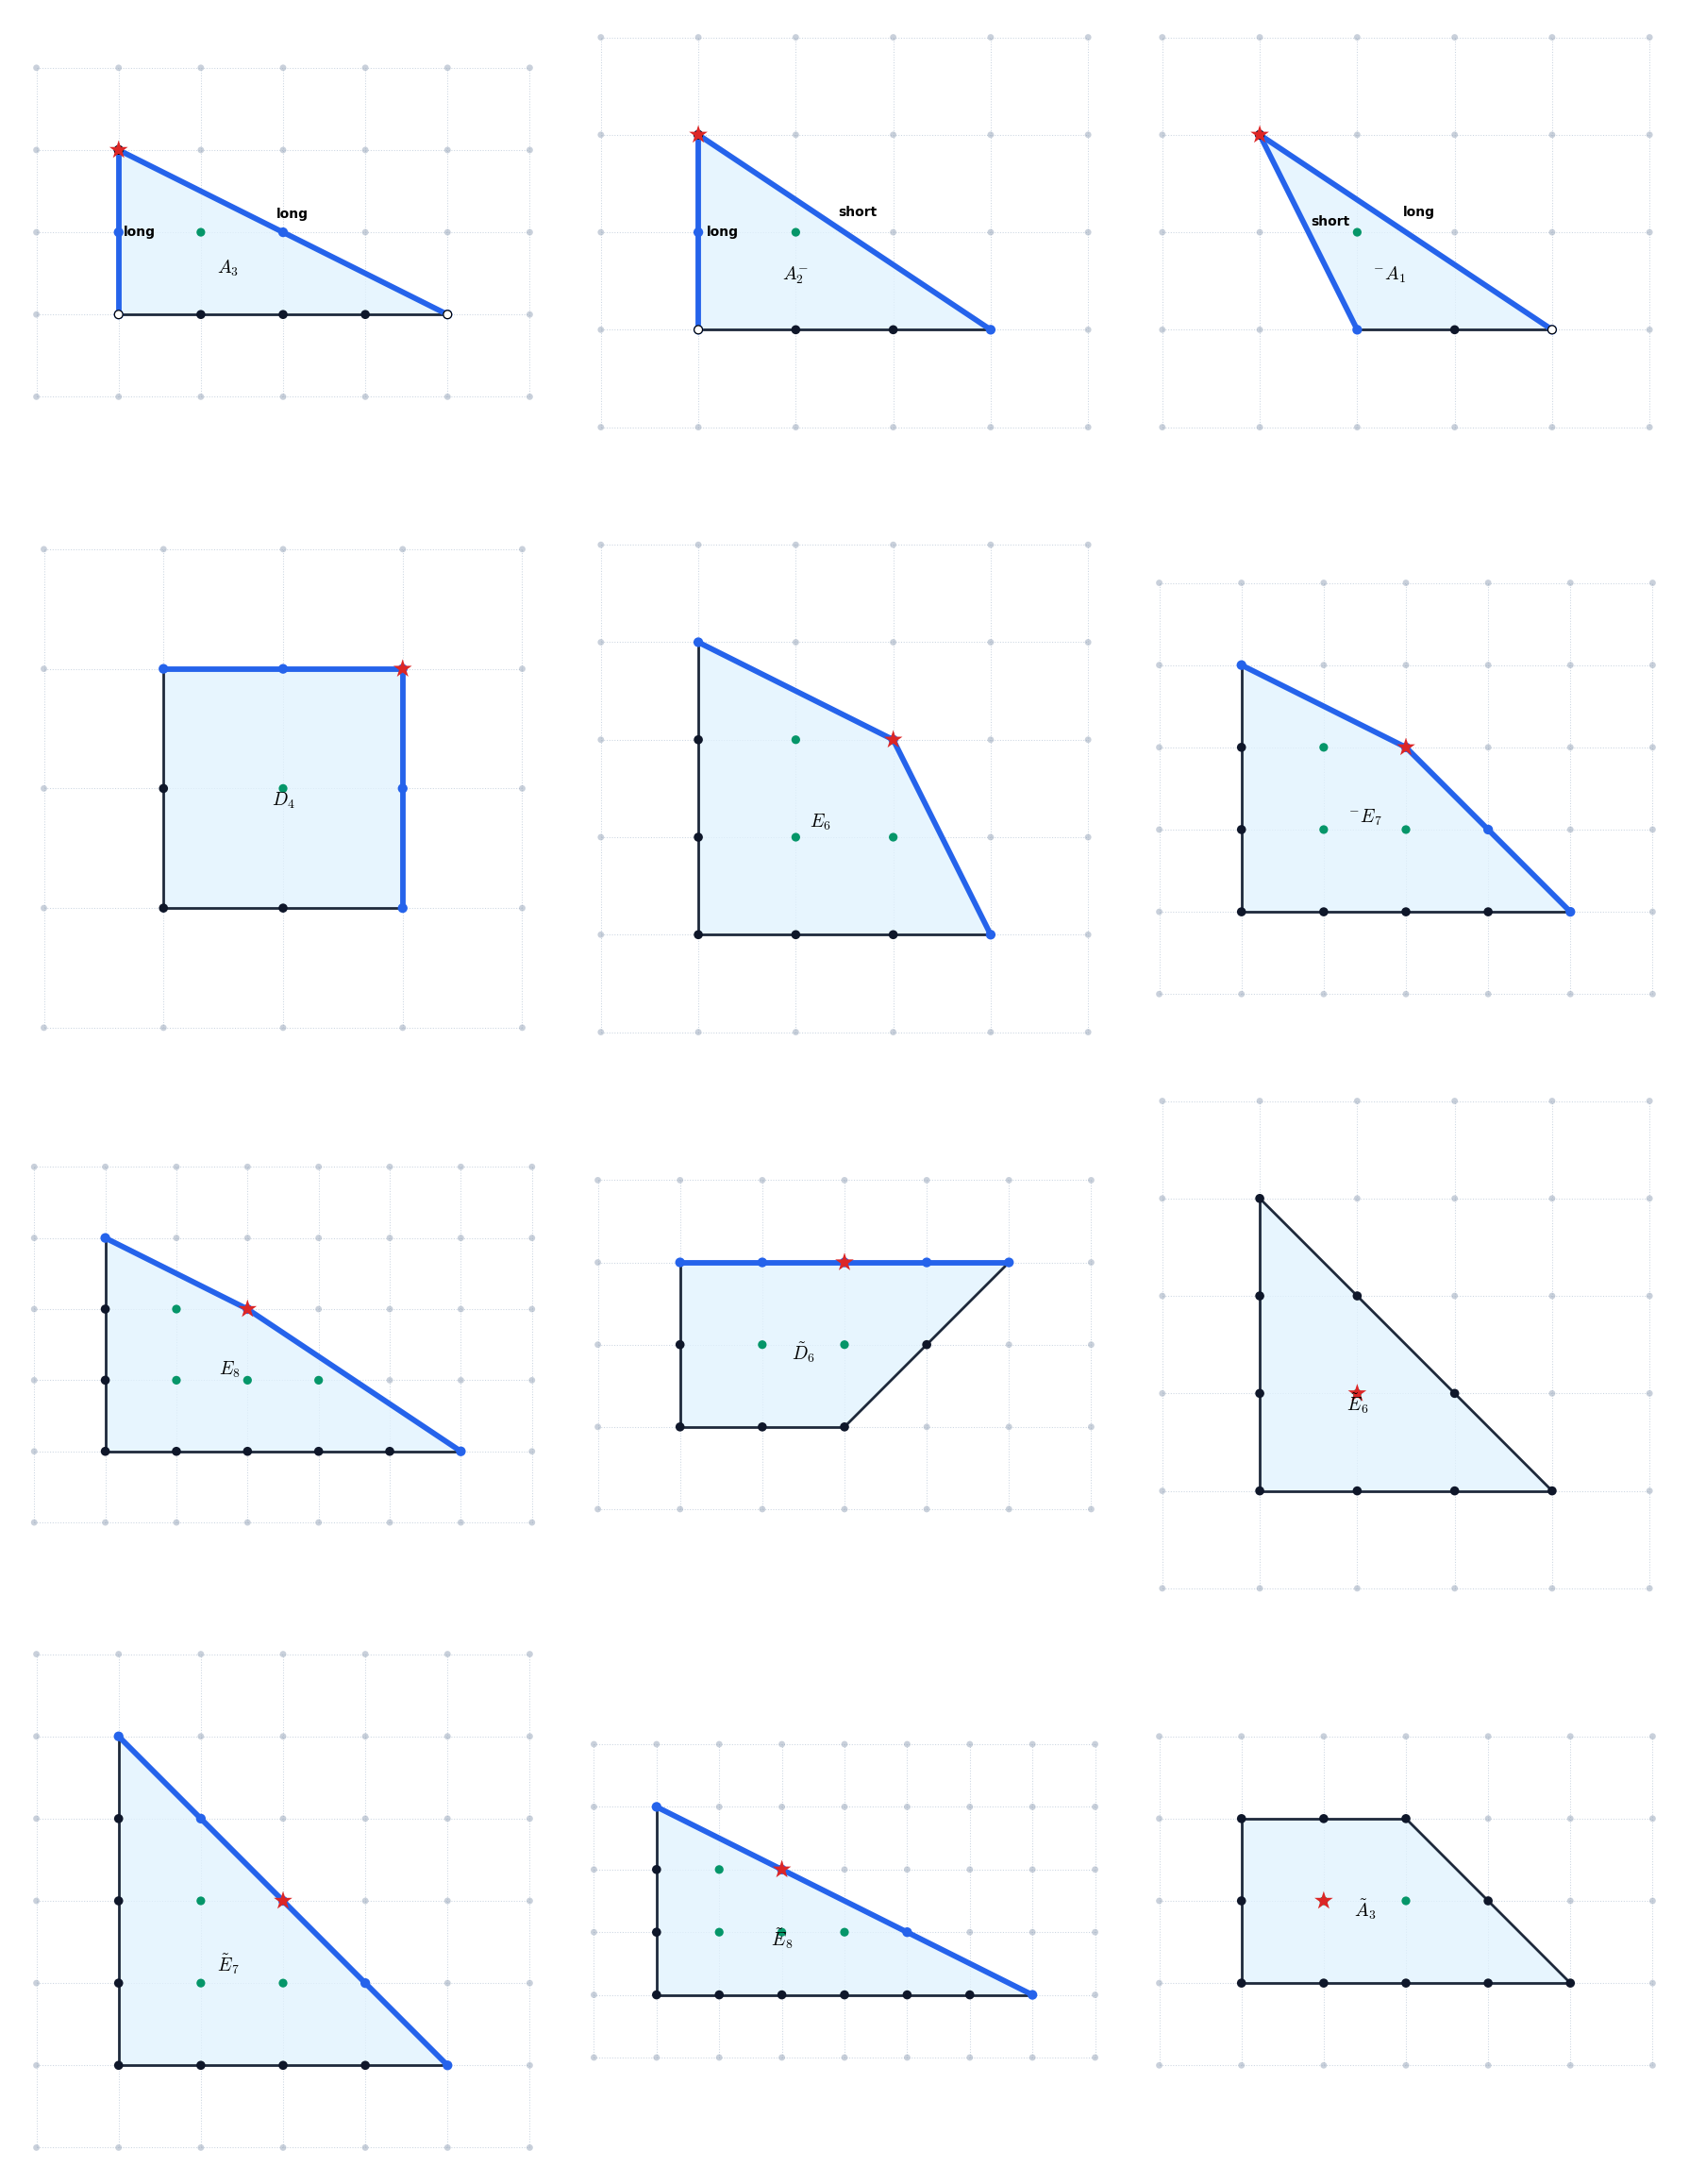

In [8]:
import os
from sage.plot.multigraphics import GraphicsArray

CANONICAL_SURFACES = [
    # Row 1: A-types
    ADESurface('A', 3, variant=('long', 'long')),
    ADESurface('A', 2, variant=('long', 'short')),
    ADESurface('A', 1, variant=('short', 'long')),
    # Row 2: D4, E6, ^-E7
    ADESurface('D', 4),
    ADESurface('E', 6),
    ADESurface('E', 7, variant=('decorated',)),
    # Row 3: E8, affine D6, affine E6
    ADESurface('E', 8),
    ADESurface('D', 6, affine=True),
    ADESurface('E', 6, affine=True),
    # Row 4: affine E7, affine E8, affine A3
    ADESurface('E', 7, affine=True),
    ADESurface('E', 8, affine=True),
    ADESurface('A', 3, affine=True),
]

pub_dir = 'ade_polytopes_publication'
os.makedirs(pub_dir, exist_ok=True)

for f in os.listdir(pub_dir):
    if f.endswith(('.pdf', '.png')):
        os.remove(os.path.join(pub_dir, f))

plots = []
for s in CANONICAL_SURFACES:
    p = s.base().plot()
    plots.append(p)
    pdf_path = os.path.join(pub_dir, f"{s.key()}.pdf")
    png_path = os.path.join(pub_dir, f"{s.key()}.png")
    p.save(pdf_path, axes=False, frame=False, figsize=[8, 8])
    p.save(png_path, axes=False, frame=False, figsize=[8, 8])
    print(f"  ✓ Exported {s.key()}")

gallery = GraphicsArray([
    plots[0:3],
    plots[3:6],
    plots[6:9],
    plots[9:12],
])

gallery.save('ade-gallery.pdf', axes=False, frame=False, figsize=[18, 24])
gallery.save('ade_gallery.png', axes=False, frame=False, figsize=[18, 24])
print("\n  ✓ Exported ade-gallery.pdf and ade_gallery.png")

gallery.show(figsize=[18, 24])